# NBA Shot Accuracy Prediction: Momentum-Aware Feature Engineering & EDA
### Princeton University - Computer Science Junior Paper
**Author:** Alexander Liu  
**Advisor:** Professor Xiaoyan Li

This notebook implements the data cleaning and exploratory data analysis (EDA) phases of your Junior Paper proposal. The goal is to prepare features that capture the "rhythm and flow" of the game—specifically momentum and fatigue—to be used in a Recurrent Neural Network (RNN).

## 1. Data Loading
We load the two primary datasets:
1. **Shot Dataset:** Contains spatial information and outcome for every shot.
2. **Play-by-Play (PBP) Dataset:** Provides the context of the game, including scores and substitutions.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

shots = pd.read_csv('NBA_2023_Shots.csv')
pbp = pd.read_csv('pbp2023.csv')

print(f"Shots Dataset: {shots.shape}")
print(f"Play-by-Play Dataset: {pbp.shape}")

Shots Dataset: (217220, 26)
Play-by-Play Dataset: (646367, 16)


## 2. Data Cleaning & Time Normalization
To join the datasets and calculate time-based momentum features, we must convert the NBA clock format into a unified 'Seconds Remaining' field.

In [ ]:
def clock_to_seconds(clock_str):
    """Converts ISO-like duration string (PT12M00.00S) to total seconds."""
    try:
        match = re.search(r'PT(\d+)M([\d.]+)S', clock_str)
        if match:
            mins, secs = match.groups()
            return int(mins) * 60 + float(secs)
        return 0
    except:
        return 0

pbp['seconds_remaining'] = pbp['clock'].apply(clock_to_seconds)

shots['seconds_remaining'] = (shots['MINS_LEFT'] * 60) + shots['SECS_LEFT']

shots = shots.sort_values(['GAME_ID', 'QUARTER', 'seconds_remaining'], ascending=[True, True, False])
print("Time normalization and sorting complete.")

Time normalization and sorting complete.


## 3. Momentum Feature Engineering
Per the proposal, we engineer three dynamic features:
1. **`fg_pct_last_5`**: A player's field goal percentage over their last 5 shots.
2. **`time_since_last_shot`**: Seconds elapsed since the player's last attempt (Fatigue/Rhythm).
3. **`score_diff`**: The home-away point margin at the time of the shot.

In [ ]:
shots['shot_val'] = shots['SHOT_MADE'].astype(int)
shots['fg_pct_last_5'] = shots.groupby(['GAME_ID', 'PLAYER_ID'])['shot_val'].transform(
    lambda x: x.shift(1).rolling(window=5, min_periods=1).mean()
)

shots['fg_pct_last_3'] = shots.groupby(['GAME_ID', 'PLAYER_ID'])['shot_val'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
)

shots['fg_pct_last_10'] = shots.groupby(['GAME_ID', 'PLAYER_ID'])['shot_val'].transform(
    lambda x: x.shift(1).rolling(window=10, min_periods=1).mean()
)

shots['prev_shot_time'] = shots.groupby(['GAME_ID', 'PLAYER_ID'])['seconds_remaining'].shift(1)
shots['time_since_last_shot'] = shots['prev_shot_time'] - shots['seconds_remaining']
shots['time_since_last_shot'] = shots['time_since_last_shot'].apply(lambda x: x if x >= 0 else 0)

pbp_scores = pbp[['gameid', 'period', 'seconds_remaining', 'h_pts', 'a_pts']].drop_duplicates()
pbp_scores = pbp_scores.rename(columns={'gameid': 'GAME_ID', 'period': 'QUARTER'})


pbp_scores['GAME_ID'] = pbp_scores['GAME_ID'].astype(int)
pbp_scores['QUARTER'] = pbp_scores['QUARTER'].astype(int)
pbp_scores['seconds_remaining'] = pbp_scores['seconds_remaining'].astype(float)

pbp_scores = pbp_scores.sort_values('seconds_remaining', ascending=True)

shots_for_merge = shots.reset_index().copy()
shots_for_merge['GAME_ID'] = shots_for_merge['GAME_ID'].astype(int)
shots_for_merge['QUARTER'] = shots_for_merge['QUARTER'].astype(int)
shots_for_merge['seconds_remaining'] = shots_for_merge['seconds_remaining'].astype(float)
shots_for_merge = shots_for_merge.sort_values('seconds_remaining', ascending=True)

merged_results = pd.merge_asof(
    shots_for_merge,
    pbp_scores,
    on='seconds_remaining',
    by=['GAME_ID', 'QUARTER'],
    direction='backward'
)

merged_results = merged_results.set_index('index')

name_to_abb = {
    'Atlanta Hawks': 'ATL', 'Boston Celtics': 'BOS', 'Brooklyn Nets': 'BKN',
    'Charlotte Hornets': 'CHA', 'Chicago Bulls': 'CHI', 'Cleveland Cavaliers': 'CLE',
    'Detroit Pistons': 'DET', 'Indiana Pacers': 'IND', 'Miami Heat': 'MIA',
    'Milwaukee Bucks': 'MIL', 'New York Knicks': 'NYK', 'Orlando Magic': 'ORL',
    'Philadelphia 76ers': 'PHI', 'Toronto Raptors': 'TOR', 'Washington Wizards': 'WAS',
    'Dallas Mavericks': 'DAL', 'Denver Nuggets': 'DEN', 'Golden State Warriors': 'GSW',
    'Houston Rockets': 'HOU', 'Los Angeles Clippers': 'LAC', 'Los Angeles Lakers': 'LAL',
    'Memphis Grizzlies': 'MEM', 'Minnesota Timberwolves': 'MIN', 'New Orleans Pelicans': 'NOP',
    'Oklahoma City Thunder': 'OKC', 'Phoenix Suns': 'PHX', 'Portland Trail Blazers': 'POR',
    'Sacramento Kings': 'SAC', 'San Antonio Spurs': 'SAS', 'Utah Jazz': 'UTA'
}

shots['TEAM_ABB_MAPPED'] = shots['TEAM_NAME'].map(name_to_abb)
shots['is_home_team'] = (shots['TEAM_ABB_MAPPED'] == shots['HOME_TEAM']).astype(int)

shots['h_pts'] = merged_results['h_pts'].fillna(0)
shots['a_pts'] = merged_results['a_pts'].fillna(0)

shots['score_diff'] = np.where(
    shots['is_home_team'] == 1,
    shots['h_pts'] - shots['a_pts'],
    shots['a_pts'] - shots['h_pts']
)

print("Feature engineering complete with player-centric score differential.")

Feature engineering complete with player-centric score differential.


## 4. Exploratory Data Analysis
We analyze the engineered features to validate if they correlate with shot success before training the Neural Network.

/tmp/ipykernel_13994/1542825968.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=shots, x='momentum_bin', y='shot_val', palette='viridis')


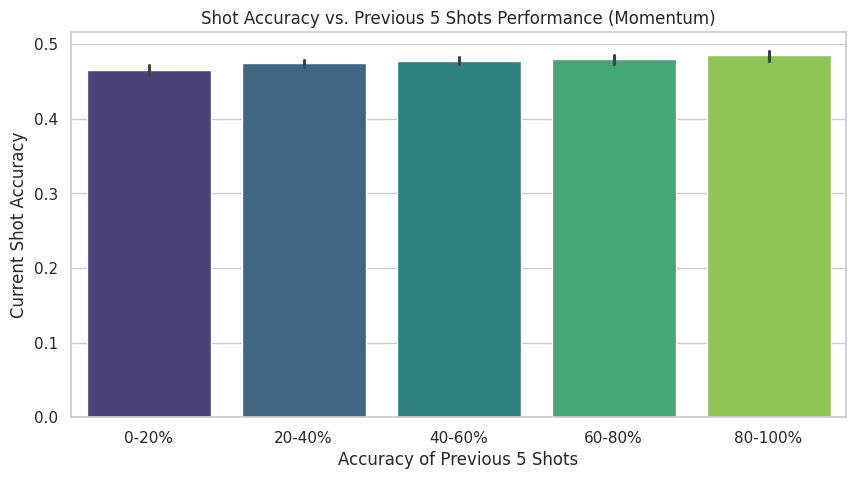

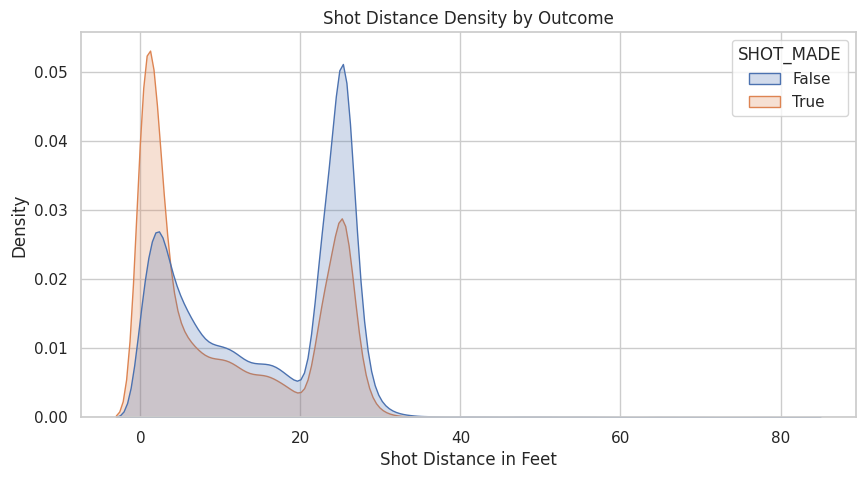

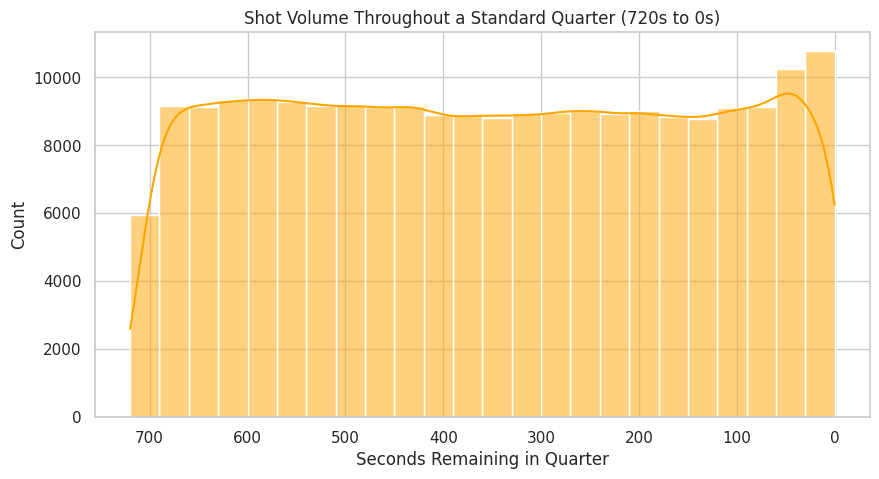

In [ ]:
sns.set_theme(style="whitegrid")

shots['momentum_bin'] = pd.cut(shots['fg_pct_last_5'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0], labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%'])
plt.figure(figsize=(10, 5))
sns.barplot(data=shots, x='momentum_bin', y='shot_val', palette='viridis')
plt.title('Shot Accuracy vs. Previous 5 Shots Performance (Momentum)')
plt.xlabel('Accuracy of Previous 5 Shots')
plt.ylabel('Current Shot Accuracy')
plt.show()


plt.figure(figsize=(10, 5))
sns.kdeplot(data=shots, x='SHOT_DISTANCE', hue='SHOT_MADE', fill=True)
plt.title('Shot Distance Density by Outcome')
plt.xlabel('Shot Distance in Feet')
plt.ylabel('Density')
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(shots['seconds_remaining'], bins=24, kde=True, color='orange')
plt.gca().invert_xaxis() # 720 to 0
plt.title('Shot Volume Throughout a Standard Quarter (720s to 0s)')
plt.xlabel('Seconds Remaining in Quarter')
plt.show()

## 5. Preparation for Deep Learning
We finalize the dataset by selecting the relevant features, handling missing values, and exporting for use in the RNN.

In [ ]:

final_features = [
    'PLAYER_ID', 'GAME_ID', 'QUARTER', 'seconds_remaining',
    'SHOT_DISTANCE', 'LOC_X', 'LOC_Y',
    'fg_pct_last_5', 'fg_pct_last_3', 'fg_pct_last_10', # Added new FG% features
    'time_since_last_shot', 'score_diff', 'is_home_team', # Added new home team feature
    'SHOT_MADE'
]

output_df = shots[final_features].fillna(0)

output_df.to_csv('NBA_Momentum_Cleaned_2013.csv', index=False)
print("Final dataset exported as 'NBA_Momentum_Cleaned_2013.csv'")

NameError: name 'shots' is not defined

## 6. Multi-Year Data Processing Loop
To extend the analysis across multiple seasons, we'll encapsulate the data cleaning and feature engineering steps into a reusable function. This function will be called for each year from 2014 to 2023, saving the processed data into an `nba_data` directory.

In [ ]:
import os
import pandas as pd
import numpy as np
import re

def process_nba_data_for_year(year):
    """Processes NBA Shots and Play-by-Play data for a given year."""

    print(f"\nProcessing data for year: {year}...")

    try:
        shots = pd.read_csv(f'NBA_{year}_Shots.csv')
        pbp = pd.read_csv(f'pbp{year}.csv')
    except FileNotFoundError:
        print(f"Skipping year {year}: Data files not found (e.g., NBA_{year}_Shots.csv or pbp{year}.csv).")
        return

    print(f"Shots Dataset ({year}): {shots.shape}")
    print(f"Play-by-Play Dataset ({year}): {pbp.shape}")

    def clock_to_seconds(clock_str):
        """Converts ISO-like duration string (PT12M00.00S) to total seconds."""
        try:
            match = re.search(r'PT(\d+)M([\d.]+)S', clock_str)
            if match:
                mins, secs = match.groups()
                return int(mins) * 60 + float(secs)
            return 0
        except:
            return 0

    pbp['seconds_remaining'] = pbp['clock'].apply(clock_to_seconds)
    shots['seconds_remaining'] = (shots['MINS_LEFT'] * 60) + shots['SECS_LEFT']
    shots = shots.sort_values(['GAME_ID', 'QUARTER', 'seconds_remaining'], ascending=[True, True, False])
    print(f"Time normalization and sorting complete for {year}.")

    shots['shot_val'] = shots['SHOT_MADE'].astype(int)
    shots['fg_pct_last_5'] = shots.groupby(['GAME_ID', 'PLAYER_ID'])['shot_val'].transform(
        lambda x: x.shift(1).rolling(window=5, min_periods=1).mean()
    )
    shots['fg_pct_last_3'] = shots.groupby(['GAME_ID', 'PLAYER_ID'])['shot_val'].transform(
        lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
    )
    shots['fg_pct_last_10'] = shots.groupby(['GAME_ID', 'PLAYER_ID'])['shot_val'].transform(
        lambda x: x.shift(1).rolling(window=10, min_periods=1).mean()
    )

    shots['prev_shot_time'] = shots.groupby(['GAME_ID', 'PLAYER_ID'])['seconds_remaining'].shift(1)
    shots['time_since_last_shot'] = shots['prev_shot_time'] - shots['seconds_remaining']
    shots['time_since_last_shot'] = shots['time_since_last_shot'].apply(lambda x: x if x >= 0 else 0)

    pbp_scores = pbp[['gameid', 'period', 'seconds_remaining', 'h_pts', 'a_pts']].drop_duplicates()
    pbp_scores = pbp_scores.rename(columns={'gameid': 'GAME_ID', 'period': 'QUARTER'})

    pbp_scores['GAME_ID'] = pbp_scores['GAME_ID'].astype(int)
    pbp_scores['QUARTER'] = pbp_scores['QUARTER'].astype(int)
    pbp_scores['seconds_remaining'] = pbp_scores['seconds_remaining'].astype(float)
    pbp_scores = pbp_scores.sort_values('seconds_remaining', ascending=True)

    shots_for_merge = shots.reset_index().copy()
    shots_for_merge['GAME_ID'] = shots_for_merge['GAME_ID'].astype(int)
    shots_for_merge['QUARTER'] = shots_for_merge['QUARTER'].astype(int)
    shots_for_merge['seconds_remaining'] = shots_for_merge['seconds_remaining'].astype(float)
    shots_for_merge = shots_for_merge.sort_values('seconds_remaining', ascending=True)

    merged_results = pd.merge_asof(
        shots_for_merge,
        pbp_scores,
        on='seconds_remaining',
        by=['GAME_ID', 'QUARTER'],
        direction='backward'
    )
    merged_results = merged_results.set_index('index')

    name_to_abb = {
        'Atlanta Hawks': 'ATL', 'Boston Celtics': 'BOS', 'Brooklyn Nets': 'BKN',
        'Charlotte Hornets': 'CHA', 'Chicago Bulls': 'CHI', 'Cleveland Cavaliers': 'CLE',
        'Detroit Pistons': 'DET', 'Indiana Pacers': 'IND', 'Miami Heat': 'MIA',
        'Milwaukee Bucks': 'MIL', 'New York Knicks': 'NYK', 'Orlando Magic': 'ORL',
        'Philadelphia 76ers': 'PHI', 'Toronto Raptors': 'TOR', 'Washington Wizards': 'WAS',
        'Dallas Mavericks': 'DAL', 'Denver Nuggets': 'DEN', 'Golden State Warriors': 'GSW',
        'Houston Rockets': 'HOU', 'Los Angeles Clippers': 'LAC', 'Los Angeles Lakers': 'LAL',
        'Memphis Grizzlies': 'MEM', 'Minnesota Timberwolves': 'MIN', 'New Orleans Pelicans': 'NOP',
        'Oklahoma City Thunder': 'OKC', 'Phoenix Suns': 'PHX', 'Portland Trail Blazers': 'POR',
        'Sacramento Kings': 'SAC', 'San Antonio Spurs': 'SAS', 'Utah Jazz': 'UTA'
    }

    shots['TEAM_ABB_MAPPED'] = shots['TEAM_NAME'].map(name_to_abb)
    shots['is_home_team'] = (shots['TEAM_ABB_MAPPED'] == shots['HOME_TEAM']).astype(int)

    shots['h_pts'] = merged_results['h_pts'].fillna(0)
    shots['a_pts'] = merged_results['a_pts'].fillna(0)

    shots['score_diff'] = np.where(
        shots['is_home_team'] == 1,
        shots['h_pts'] - shots['a_pts'],
        shots['a_pts'] - shots['h_pts']
    )
    print(f"Feature engineering complete for {year} with player-centric score differential.")

    final_features = [
        'PLAYER_ID', 'GAME_ID', 'QUARTER', 'seconds_remaining',
        'SHOT_DISTANCE', 'LOC_X', 'LOC_Y',
        'fg_pct_last_5', 'fg_pct_last_3', 'fg_pct_last_10',
        'time_since_last_shot', 'score_diff', 'is_home_team',
        'SHOT_MADE'
    ]

    output_df = shots[final_features].fillna(0)

    output_filename = f'nba_data/NBA_Momentum_Cleaned_{year}.csv'
    output_df.to_csv(output_filename, index=False)
    print(f"Final dataset exported as '{output_filename}'")
output_dir = 'nba_data'
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory '{output_dir}' ensured.")


Output directory 'nba_data' ensured.


In [ ]:
for year in range(2014, 2024):
    process_nba_data_for_year(year)

print("\nAll specified years processed.")


Processing data for year: 2014...
Shots Dataset (2014): (204126, 26)
Play-by-Play Dataset (2014): (632199, 16)
Time normalization and sorting complete for 2014.
Feature engineering complete for 2014 with player-centric score differential.
Final dataset exported as 'nba_data/NBA_Momentum_Cleaned_2014.csv'

Processing data for year: 2015...
Shots Dataset (2015): (205550, 26)
Play-by-Play Dataset (2015): (633526, 16)
Time normalization and sorting complete for 2015.
Feature engineering complete for 2015 with player-centric score differential.
Final dataset exported as 'nba_data/NBA_Momentum_Cleaned_2015.csv'

Processing data for year: 2016...
Shots Dataset (2016): (207893, 26)
Play-by-Play Dataset (2016): (641644, 16)
Time normalization and sorting complete for 2016.
Feature engineering complete for 2016 with player-centric score differential.
Final dataset exported as 'nba_data/NBA_Momentum_Cleaned_2016.csv'

Processing data for year: 2017...
Shots Dataset (2017): (209929, 26)
Play-by-P